We start by showing a simple example of a logistic regression. An iterative optimization method is performed in order to minimize the binary cross-entropy loss function

$$
L=\frac{1}{N}\sum_{i=1}^N [ -y_i \log (p(y_i)) - (1-y_i) \log (1-p(y_i))]
$$,

where y_i are binary outputs (0 or 1). The probability is modeled as a sigmoid function

$$
p(y)=\frac{1}{1+e^{-(\alpha y + \beta)}}
$$

In [2]:
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt
from statsmodels.stats.weightstats import ztest
from scipy import stats

In [2]:
#Reshaped for Logistic function.
X = np.array([3.78, 2.44, 2.09, 0.14, 1.72, 1.65, 4.92, 4.37, 4.96, 4.52, 3.69, 5.88]).reshape(-1,1)
y = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

logr = linear_model.LogisticRegression()
logr.fit(X,y)

#predict if tumor is cancerous where the size is 3.46mm:
predicted = logr.predict(np.array([3.46]).reshape(-1,1))
print(predicted) 

[0]


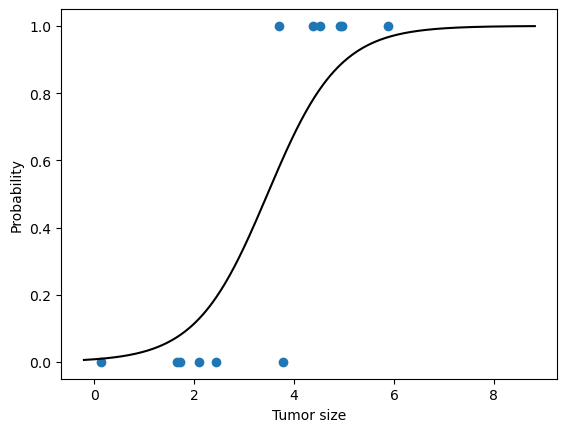

In [5]:
plt.scatter(X, y)

vals = np.linspace(-1.5*X.min(), 1.5*X.max(), 400).reshape(-1,1)

# Evaluate the fitted logistic function
probs = logr.predict_proba(vals)[:,1]

plt.plot(vals, probs, 'k')

plt.xlabel("Tumor size")
plt.ylabel("Probability")
plt.show()

In [6]:
print(logr.coef_)
print(logr.intercept_)

[[1.39514829]]
[-4.83687979]


Quick review of statistical tests.

**Z-test**: Let's suppose we have a sample $S$ of size $n$ from a random variable $X$ with approximately a normal distribution, and we want to determine whether it is equal to some reference value $\mu_0$. Then, we compute the Z-score of $\mu_0$ in this sample:

$$Z = \frac{\langle X \rangle _S-\mu_0}{\Delta X_S/\sqrt{n}},$$

and the so-called p-value. Now we formulate our **null hypothesis** (the opposite of the fact we want to assert):

Two-tailed: THE MEASSURED VARIABLE IS DIFFERENT FROM $\mu_0$ WITH A SIGNIFICANCE LEVEL OF $\alpha$.
The p-value is  2(1-CDF(Z)).

Right-tailed: THE SAMPLE IS GREATER THAN $\mu_0$ WITH A SIGNIFICANCE LEVEL OF $\alpha$.
The p-value is 1-CDF(Z).

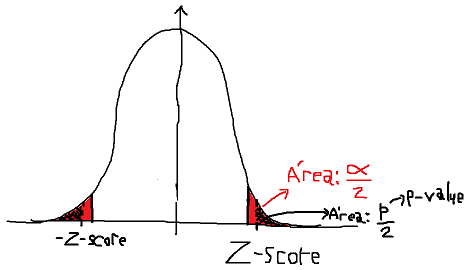

If p > $\alpha$ (or $Z$ greater than the critical value), the null hypothesis is accepted.

In [9]:
alpha = 0.05
sample = np.random.uniform(-1,1, 500)
ztest_score, pval = ztest(sample,value=0.2,alternative='two-sided')

if(pval>alpha):
     print('Null hypothesis is accepted!')
else:
    print('Null hypothesis is rejected. \nAlternate hypothesis is accepted!')   

Null hypothesis is rejected. 
Alternate hypothesis is accepted!


In [10]:
print(np.mean(sample), np.std(sample)/np.sqrt(len(sample)))
print(ztest_score, pval)

0.026549016503596243 0.026305394389318146
-6.587144945864962 4.4836452812332195e-11


Two-sample Z-test.
Now, let's suppose we have two samples, 1 and 2, from different populations, which means are $\mu_1$ and $\mu_2$, respectively. We want to infer if the values for each population are equal (two-tailed), or if one greater than the other. For this, we compute the two-sample Z-score:

$$
Z=\frac{\langle X_1\rangle - \langle X_2\rangle - \left(\mu_1 - \mu_2\right)}{\sqrt{\frac{\Delta X_1^2}{n_1}+ \frac{\Delta X_2^2}{n_2}}}
$$

Our null hypothesis will be that the populations have no difference in their values.

In [5]:
alpha = 0.05
sample1 = np.random.uniform(-1,1, 50)
sample2 = np.random.normal(0.25, 1, 100)

ztest_score, pval = ztest(x1=sample1, x2=sample2, value=0.25, alternative='two-sided')

if(pval>alpha):
     print('Null hypothesis is accepted!')
else:
    print('Null hypothesis is rejected. \nAlternate hypothesis is accepted!') 

Null hypothesis is rejected. 
Alternate hypothesis is accepted!


In this case, we showed that a sample of size 50 from a (-1,1) uniform variable and a sample of size 100 from a normal variable centered in 0.25 provide enough evidence to assert that they are different with a 95% level of confidence.

**Pearson's $\chi^2$ test**: there are several versions of this test. Two of the most useful are assessing goodness of a fit, and testing for statistical independence. Essentially, we propose as the null hypothesis that the measured outcomes $O_i$ are equal to some hypothetical value $E_i$, usually determined by the fitting model or the probability distribution we guess the sample has. The $\chi^2$ test statistic is computed as

$$
\chi^2 =\sum_i \frac{(O_i- E_i)^2}{E_i},
$$

this is, the sum of the squared residuals, relative to the hypothetical value. We need to compute the number of degrees of freedom. For a goodness of fit test, it is equal to $N-1$, with $N$ the size of the sample. For a statistical independence test, it is equal to $(n_A-1)(n_B-1)$, with $n_{A(B)}$ the number of observations of the $A(B)$ variable. Then, we observe in a $\chi^2$ table whether or not it surpasses the critical value determined by the desired level of confidence.

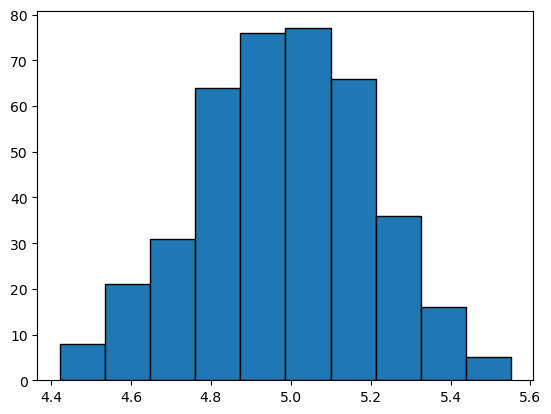

In [27]:
dat = np.random.uniform(0., 10., 80000)
clustered = [np.mean(dat[200*i:(200*(1+i))]) for i in range(400)]
clustered = np.sort(clustered)
counts, bins = np.histogram(clustered, bins=20)
plt.hist(clustered, edgecolor='black')
plt.show()

I test how good the Central Limit Theorem approximates the distribution of 400 points, each one consisting of the average of 200 random numbers with a uniform distribution in [0, 10]. The distribution should approximately be normal, centered in 5 and with a standard deviation of $10/\sqrt{12*200}\approx 0.2$.

In [31]:
rv = stats.norm(5., 10./np.sqrt(12.*200.))
testcounts = 400 * (rv.cdf(bins[1:]) - rv.cdf(bins[:-1]))
testcounts *= counts.sum() / testcounts.sum()

chistd, pval = stats.chisquare(counts, testcounts)
print(f"chistd: {chistd}\np-value: {pval}")

chistd: 35.230548664890804
p-value: 0.013099962984733118


0.013099962984733118


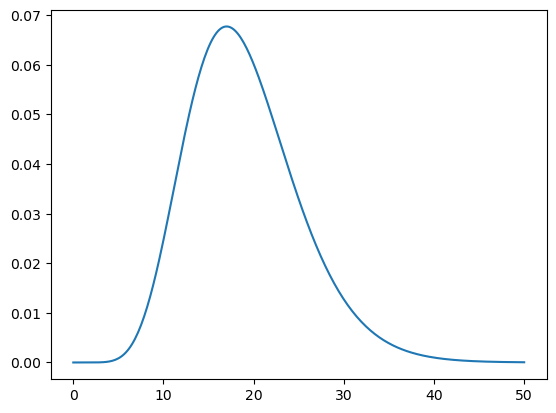

In [34]:
print(stats.chi2.sf(chistd, len(counts)-1))
tlist = np.linspace(0., 50., 300)
plt.plot(tlist, stats.chi2.pdf(tlist, len(counts)-1))
plt.show()

We can conclude that the sample provides enough evidence to assess that the central limit theorem in this case is satisfied with a confidence level of $\approx 98.7\%$.